In [1]:
import scanpy as sc

In [2]:
import pandas as pd

In [3]:
adata = sc.read_csv('/Users/qiaoqiaowan/Desktop/python/scRNA-seq/GSM5226574_C51ctr_raw_counts.csv').T
print(adata.X.shape)

(6099, 34546)


Doublet removal

In [4]:
import scvi

/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
adata

AnnData object with n_obs × n_vars = 6099 × 34546

In [ ]:
adata.layers['counts'] = adata.X.copy()
sc.pp.filter_genes(adata, min_cells = 10)
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = False, flavor = 'seurat_v3',layer='counts') #train scvi with top 2000 highly variable genes
adata_hvg = adata[:, adata.var['highly_variable']].copy() #subset the adata with highly variable genes

scvi.model.SCVI.setup_anndata(adata_hvg, layer = 'counts' )


In [7]:
vae = scvi.model.SCVI(adata_hvg)
vae.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [06:40<00:00,  1.07it/s, v_num=1, train_loss=323]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [06:40<00:00,  1.00s/it, v_num=1, train_loss=323]


In [ ]:
adata #gene number reduced by filtering out lowly expressed genes min_cell = 10 

AnnData object with n_obs × n_vars = 6099 × 19896
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'
    layers: 'counts'

In [9]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train()

INFO     Creating doublets, preparing SOLO model.                                                                  


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connect

Epoch 285/400:  71%|███████▏  | 285/400 [01:17<00:31,  3.67it/s, v_num=1, train_loss_step=0.259, train_loss_epoch=0.29] 
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.269. Signaling Trainer to stop.


In [10]:
df = solo.predict()
df['prediction'] = solo.predict(soft = False)

df.index = df.index.map(str) 

df

/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,doublet,singlet,prediction
TAGGTACCATGGCCAC-1_1,0.812424,0.187576,doublet
ATTCACTGTAACAGGC-1_1,0.879022,0.120979,doublet
TAACTTCCAACCACGC-1_1,0.620395,0.379605,doublet
TTGGGTACACGACAAG-1_1,0.811746,0.188254,doublet
AGGCCACAGAGTCACG-1_1,0.820924,0.179076,doublet
...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.010930,0.989070,singlet
CACTGGGGTCTACGTA-1_1,0.000993,0.999007,singlet
CATACTTGTAGAGGAA-1_1,0.008278,0.991722,singlet
TTTGGTTTCCACGGAC-1_1,0.001722,0.998278,singlet


In [11]:
df.groupby('prediction').count()

,doublet,singlet
prediction,,
doublet,1072,1072
singlet,5027,5027


In [12]:
df['dif'] = df.doublet - df.singlet
df

,doublet,singlet,prediction,dif
TAGGTACCATGGCCAC-1_1,0.812424,0.187576,doublet,0.624849
ATTCACTGTAACAGGC-1_1,0.879022,0.120979,doublet,0.758043
TAACTTCCAACCACGC-1_1,0.620395,0.379605,doublet,0.240789
TTGGGTACACGACAAG-1_1,0.811746,0.188254,doublet,0.623491
AGGCCACAGAGTCACG-1_1,0.820924,0.179076,doublet,0.641848
...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.010930,0.989070,singlet,-0.978140
CACTGGGGTCTACGTA-1_1,0.000993,0.999007,singlet,-0.998013
CATACTTGTAGAGGAA-1_1,0.008278,0.991722,singlet,-0.983444
TTTGGTTTCCACGGAC-1_1,0.001722,0.998278,singlet,-0.996556


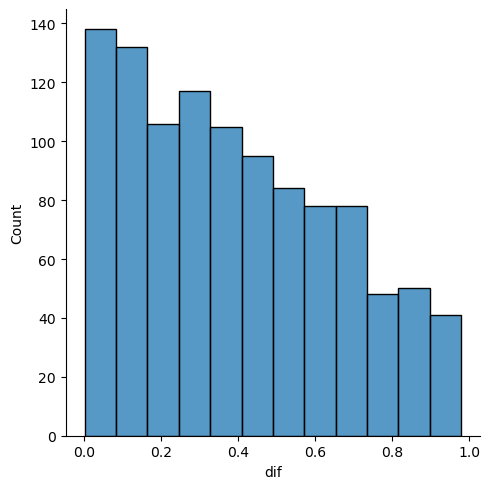

In [13]:
import seaborn as sns
sns.displot(df[df.prediction == 'doublet'], x = 'dif')

In [ ]:
doublets = df[(df.prediction == 'doublet')  & (df.dif > 0.5)] #threshold for doublet prediction, you can adjust it based on the distribution of dif values in doublets and singlets
doublets

,doublet,singlet,prediction,dif
TAGGTACCATGGCCAC-1_1,0.812424,0.187576,doublet,0.624849
ATTCACTGTAACAGGC-1_1,0.879022,0.120979,doublet,0.758043
TTGGGTACACGACAAG-1_1,0.811746,0.188254,doublet,0.623491
AGGCCACAGAGTCACG-1_1,0.820924,0.179076,doublet,0.641848
CACTGAAGTCGAAGCA-1_1,0.806107,0.193893,doublet,0.612214
...,...,...,...,...
CGCATGGAGTAAGAGG-1_1,0.864155,0.135845,doublet,0.728311
TCTATACGTTCAAGGG-1_1,0.774046,0.225954,doublet,0.548091
GCACGTGTCACACCGG-1_1,0.777058,0.222942,doublet,0.554115
CAATACGCAATGTGGG-1_1,0.778198,0.221802,doublet,0.556397


In [15]:
import pandas as pd
adata.obs = pd.DataFrame(index=adata.obs_names)

In [16]:
adata.obs['doublet'] = adata.obs.index.isin(doublets.index)

In [17]:
adata.obs

,doublet
TAGGTACCATGGCCAC-1_1,True
ATTCACTGTAACAGGC-1_1,True
TAACTTCCAACCACGC-1_1,False
TTGGGTACACGACAAG-1_1,True
AGGCCACAGAGTCACG-1_1,True
...,...
CGCCATTGTTTGCCGG-1_1,False
CACTGGGGTCTACGTA-1_1,False
CATACTTGTAGAGGAA-1_1,False
TTTGGTTTCCACGGAC-1_1,False


In [18]:
adata = adata[~adata.obs.doublet]

In [19]:
adata

View of AnnData object with n_obs × n_vars = 5733 × 19896
    obs: 'doublet'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'
    layers: 'counts'

QC - remove MT, Ribo high cells

In [ ]:
adata.var['mt'] = adata.var.index.str.startswith('MT-')#annotate mitochondrial genes based on gene names starting with MT-

/var/folders/m6/46ff4qfn7zj41m5q1v2jsc140000gp/T/ipykernel_31978/310233584.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['mt'] = adata.var.index.str.startswith('MT-')


In [21]:
adata.var

,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,mt
AL627309.5,33,False,NaN,0.005411,0.005382,0.870674,False
LINC01409,274,False,NaN,0.048697,0.054204,0.834926,False
LINC01128,81,False,NaN,0.013773,0.014569,0.871889,False
LINC00115,15,False,NaN,0.002459,0.002454,0.924167,False
SAMD11,16,False,NaN,0.002951,0.003927,1.210509,False
...,...,...,...,...,...,...,...
MAFIP,34,False,NaN,0.005575,0.005545,0.867764,False
AC011043.1,11,False,NaN,0.001968,0.002292,1.113385,False
AL354822.1,133,False,NaN,0.022627,0.024086,0.852185,False
AL592183.1,1003,False,NaN,0.198721,0.247155,0.715881,False


In [22]:
ribo_url = "http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt"

In [ ]:
ribo_genes = pd.read_table('/Users/qiaoqiaowan/Desktop/python/KEGG_RIBOSOME.v2026.1.Hs.txt', skiprows=2, header = None) #connection to local file, you can also directly read from the url using pd.read_table(ribo_url, skiprows=2, header = None)
ribo_genes

,0
0,FAU
1,MRPL13
2,RPL10
3,RPL10A
4,RPL10L
...,...
83,RPS9
84,RPSA
85,RSL24D1
86,RSL24D1P11


In [24]:
adata.var['ribo'] = adata.var_names.isin(ribo_genes[0].values)

In [25]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

In [26]:
adata.obs

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
TAACTTCCAACCACGC-1_1,False,5097,15573.0,221.0,1.419123,209.0,1.342066
TTACCGCCACTCAGAT-1_1,False,4121,11346.0,39.0,0.343733,5.0,0.044068
TTGGTTTTCCTAGCTC-1_1,False,3873,11441.0,463.0,4.046849,13.0,0.113626
CGCATAACATGCCGGT-1_1,False,3678,8491.0,119.0,1.401484,25.0,0.294429
TCTATCACAAGGCTTT-1_1,False,3560,8254.0,183.0,2.217107,5.0,0.060577
...,...,...,...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,False,354,409.0,3.0,0.733496,0.0,0.000000
CACTGGGGTCTACGTA-1_1,False,346,403.0,0.0,0.000000,0.0,0.000000
CATACTTGTAGAGGAA-1_1,False,359,409.0,2.0,0.488998,0.0,0.000000
TTTGGTTTCCACGGAC-1_1,False,299,405.0,0.0,0.000000,2.0,0.493827


In [27]:
adata.var.sort_values('n_cells_by_counts')

,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
AC108451.1,10,False,NaN,0.001640,0.001637,0.987032,False,False,5,0.000872,99.912786,5.0
NR1D1,11,False,NaN,0.001804,0.001801,0.968856,False,False,5,0.000872,99.912786,5.0
GFER,12,False,NaN,0.002131,0.002455,1.087242,False,False,6,0.001047,99.895343,6.0
RPL39,10,False,NaN,0.001968,0.002620,1.272709,False,True,6,0.001221,99.895343,7.0
MCM2,14,False,NaN,0.002295,0.002291,0.932238,False,False,6,0.001047,99.895343,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
AKAP13,4458,False,NaN,3.054271,19.760747,0.788039,False,False,4125,2.847549,28.048142,16325.0
MBNL1,4554,False,NaN,2.877029,13.180022,0.584434,False,False,4215,2.695273,26.478284,15452.0
NEAT1,4546,True,1569.0,5.314150,104.575941,1.524690,False,False,4217,4.964068,26.443398,28459.0
ZBTB20,4699,False,NaN,2.601082,7.747529,0.410402,False,False,4355,2.429618,24.036281,13929.0


In [28]:
sc.pp.filter_genes(adata, min_cells=3)

In [29]:
adata.var.sort_values('n_cells_by_counts')

,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
AC108451.1,5,False,NaN,0.001640,0.001637,0.987032,False,False,5,0.000872,99.912786,5.0
NR1D1,5,False,NaN,0.001804,0.001801,0.968856,False,False,5,0.000872,99.912786,5.0
GFER,6,False,NaN,0.002131,0.002455,1.087242,False,False,6,0.001047,99.895343,6.0
RPL39,6,False,NaN,0.001968,0.002620,1.272709,False,True,6,0.001221,99.895343,7.0
MCM2,6,False,NaN,0.002295,0.002291,0.932238,False,False,6,0.001047,99.895343,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
AKAP13,4125,False,NaN,3.054271,19.760747,0.788039,False,False,4125,2.847549,28.048142,16325.0
MBNL1,4215,False,NaN,2.877029,13.180022,0.584434,False,False,4215,2.695273,26.478284,15452.0
NEAT1,4217,True,1569.0,5.314150,104.575941,1.524690,False,False,4217,4.964068,26.443398,28459.0
ZBTB20,4355,False,NaN,2.601082,7.747529,0.410402,False,False,4355,2.429618,24.036281,13929.0


In [30]:
adata.obs.sort_values('n_genes_by_counts')

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
TAGGGTTTCTGGCTGG-1_1,False,271,414.0,1.0,0.241546,1.0,0.241546
TGACAGTTCTAAACGC-1_1,False,273,409.0,0.0,0.000000,0.0,0.000000
CGTGCTTCAAAGGGCT-1_1,False,276,431.0,41.0,9.512761,0.0,0.000000
CTCTGGTCACGACGAA-1_1,False,282,404.0,0.0,0.000000,0.0,0.000000
GGCTGTGTCTAACGCA-1_1,False,283,593.0,45.0,7.588532,12.0,2.023609
...,...,...,...,...,...,...,...
GTCATTTGTATCTCGA-1_1,False,3856,7579.0,43.0,0.567357,59.0,0.778467
TTGGTTTTCCTAGCTC-1_1,False,3873,11441.0,463.0,4.046849,13.0,0.113626
ATCCACCAGAGGTATT-1_1,False,3898,8270.0,191.0,2.309553,34.0,0.411125
TTACCGCCACTCAGAT-1_1,False,4121,11346.0,39.0,0.343733,5.0,0.044068


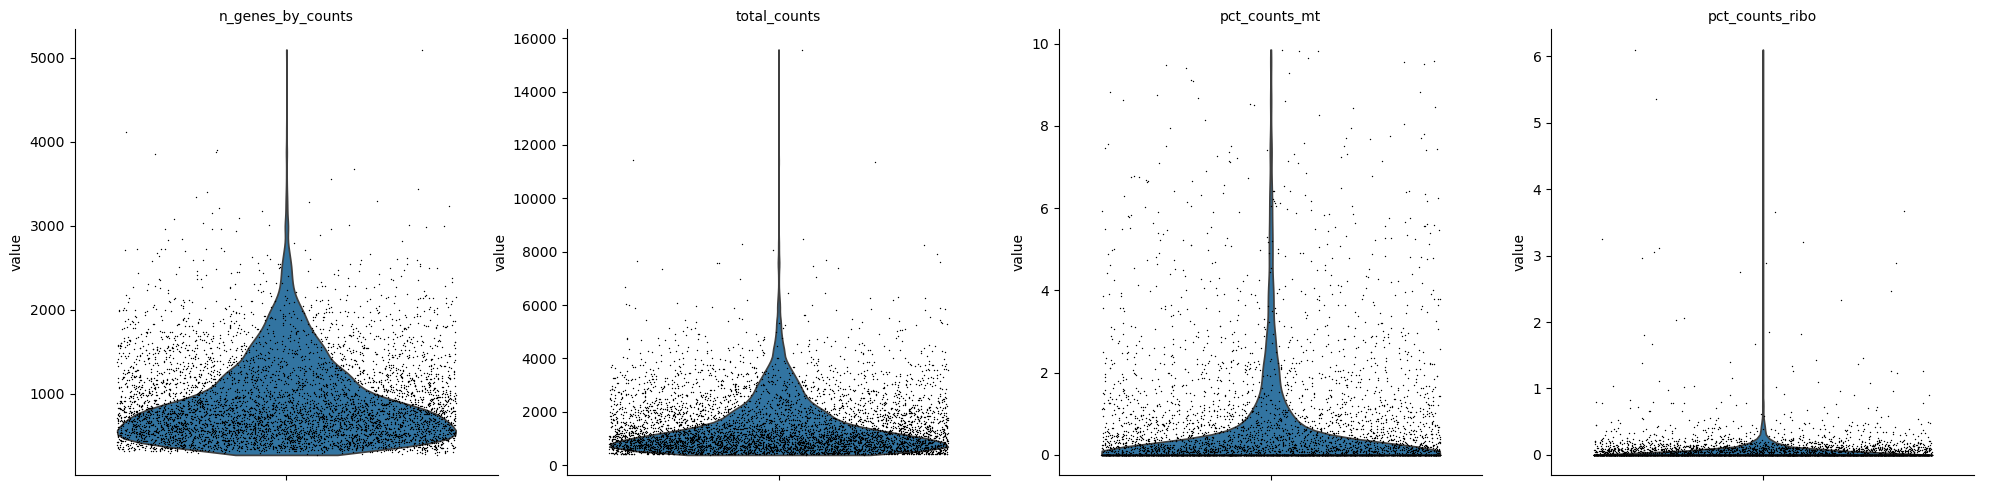

In [31]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'], 
             jitter=0.4, multi_panel=True)

In [32]:
import numpy as np

In [ ]:
upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98) #filter out cells with n_genes_by_counts higher than 98% quantile, you can adjust the threshold based on the distribution of n_genes_by_counts in your data

In [34]:
upper_lim

np.float64(2280.4399999999987)

In [35]:
data = adata[adata.obs.n_genes_by_counts < upper_lim]

In [36]:
adata.obs

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
TAACTTCCAACCACGC-1_1,False,5097,15573.0,221.0,1.419123,209.0,1.342066
TTACCGCCACTCAGAT-1_1,False,4121,11346.0,39.0,0.343733,5.0,0.044068
TTGGTTTTCCTAGCTC-1_1,False,3873,11441.0,463.0,4.046849,13.0,0.113626
CGCATAACATGCCGGT-1_1,False,3678,8491.0,119.0,1.401484,25.0,0.294429
TCTATCACAAGGCTTT-1_1,False,3560,8254.0,183.0,2.217107,5.0,0.060577
...,...,...,...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,False,354,409.0,3.0,0.733496,0.0,0.000000
CACTGGGGTCTACGTA-1_1,False,346,403.0,0.0,0.000000,0.0,0.000000
CATACTTGTAGAGGAA-1_1,False,359,409.0,2.0,0.488998,0.0,0.000000
TTTGGTTTCCACGGAC-1_1,False,299,405.0,0.0,0.000000,2.0,0.493827


In [ ]:
adata = adata[adata.obs.pct_counts_mt < 20] #filter out cells with pct_counts_mt higher than 20, you can adjust the threshold based on the distribution of pct_counts_mt in your data

In [38]:
adata = adata[adata.obs.pct_counts_ribo < 2]

In [39]:
adata

View of AnnData object with n_obs × n_vars = 5717 × 19896
    obs: 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'hvg'
    layers: 'counts'

Normalization 

In [40]:
adata.X.sum(axis = 1)

array([15573., 11346., 11441., ...,   409.,   405.,   409.],
      shape=(5717,), dtype=float32)

In [41]:
sc.pp.normalize_total(adata, target_sum=1e4)

/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [42]:
adata.X.sum(axis = 1)

array([10000.   , 10000.   , 10000.   , ..., 10000.001, 10000.   ,
       10000.   ], shape=(5717,), dtype=float32)

In [43]:
sc.pp.log1p(adata)

In [44]:
adata.X.sum(axis = 1)

array([4486.323  , 4137.889  , 3995.052  , ..., 1188.8802 , 1022.75116,
       1160.4648 ], shape=(5717,), dtype=float32)

In [45]:
adata.raw = adata

Top 2000 genes for Clustering

In [46]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000)

In [47]:
adata.var

,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,dispersions,dispersions_norm
AL627309.5,26,False,NaN,0.028381,0.005382,0.870674,False,False,26,0.004535,99.546485,26.0,2.298139,-0.248262
LINC01409,241,False,NaN,0.267370,0.054204,0.834926,False,False,241,0.045700,95.796267,262.0,2.316245,-0.182029
LINC01128,70,False,NaN,0.107560,0.014569,0.871889,False,False,70,0.012733,98.778999,73.0,2.512022,0.534141
LINC00115,14,False,NaN,0.012926,0.002454,0.924167,False,False,14,0.002442,99.755800,14.0,1.978506,-1.417502
SAMD11,16,False,NaN,0.026857,0.003927,1.210509,False,False,16,0.003140,99.720914,18.0,2.487030,0.442718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MAFIP,27,False,NaN,0.037524,0.005545,0.867764,False,False,27,0.004710,99.529042,27.0,2.516252,0.549612
AC011043.1,10,False,NaN,0.011906,0.002292,1.113385,False,False,10,0.001744,99.825571,10.0,2.393157,0.099323
AL354822.1,120,False,NaN,0.153794,0.024086,0.852185,False,False,120,0.021629,97.906855,124.0,2.405410,0.144145
AL592183.1,891,False,NaN,0.874356,0.247155,0.715881,False,False,891,0.184546,84.458399,1058.0,2.494938,-0.396399


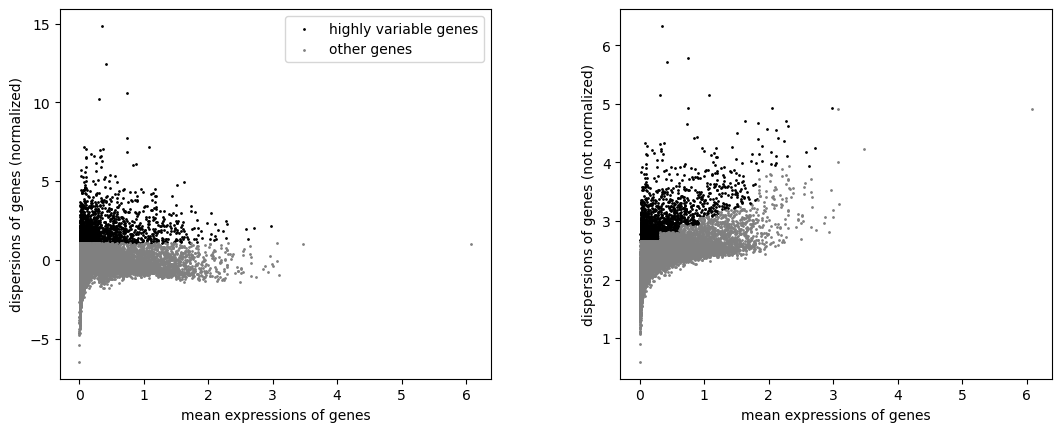

In [48]:
sc.pl.highly_variable_genes(adata)

In [49]:
adata = adata[:, adata.var.highly_variable]

In [50]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo'])

/usr/local/Caskroom/miniforge/base/envs/scanpy-env/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [51]:
sc.pp.scale(adata, max_value=10)

In [52]:
sc.tl.pca(adata, svd_solver='arpack')

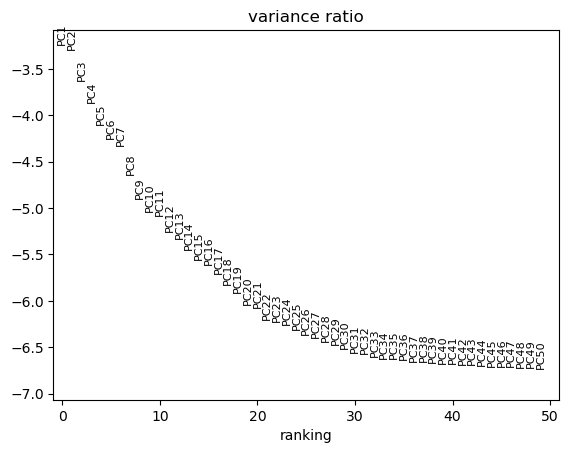

In [53]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

In [54]:
sc.pp.neighbors(adata, n_pcs = 30)

In [55]:
sc.tl.umap(adata)

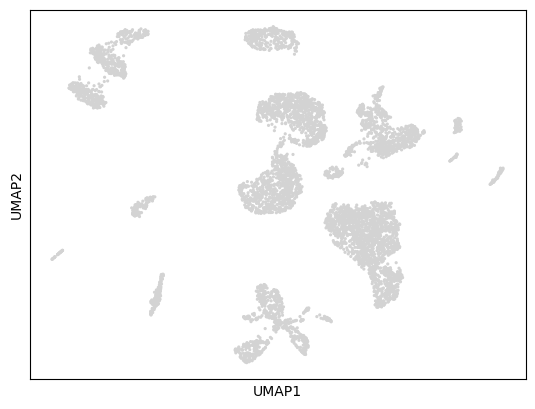

In [56]:
sc.pl.umap(adata)

In [57]:
sc.tl.leiden(adata, resolution = 0.5)

/var/folders/m6/46ff4qfn7zj41m5q1v2jsc140000gp/T/ipykernel_31978/3246266323.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.5)


In [58]:
adata.obs


,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,leiden
TAACTTCCAACCACGC-1_1,False,5097,15573.0,221.0,1.419123,209.0,1.342066,10
TTACCGCCACTCAGAT-1_1,False,4121,11346.0,39.0,0.343733,5.0,0.044068,6
TTGGTTTTCCTAGCTC-1_1,False,3873,11441.0,463.0,4.046849,13.0,0.113626,10
CGCATAACATGCCGGT-1_1,False,3678,8491.0,119.0,1.401484,25.0,0.294429,6
TCTATCACAAGGCTTT-1_1,False,3560,8254.0,183.0,2.217107,5.0,0.060577,10
...,...,...,...,...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,False,354,409.0,3.0,0.733496,0.0,0.000000,6
CACTGGGGTCTACGTA-1_1,False,346,403.0,0.0,0.000000,0.0,0.000000,1
CATACTTGTAGAGGAA-1_1,False,359,409.0,2.0,0.488998,0.0,0.000000,0
TTTGGTTTCCACGGAC-1_1,False,299,405.0,0.0,0.000000,2.0,0.493827,12


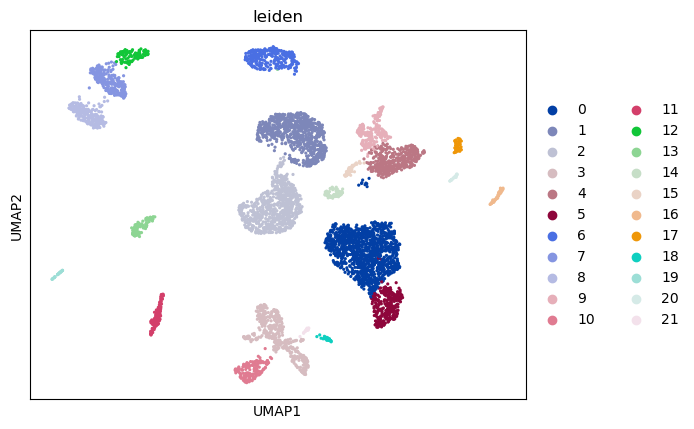

In [59]:
sc.pl.umap(adata, color=['leiden'])